In [1]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch

In [2]:
df = sns.load_dataset("penguins")
df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


In [3]:
df['species'].value_counts()

species
Adelie       152
Gentoo       124
Chinstrap     68
Name: count, dtype: int64

In [4]:
df.isna().sum()

species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64

In [5]:
df['island'].value_counts()

island
Biscoe       168
Dream        124
Torgersen     52
Name: count, dtype: int64

In [6]:
df[df.isna().any(axis=1)]

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
8,Adelie,Torgersen,34.1,18.1,193.0,3475.0,NaN
9,Adelie,Torgersen,42.0,20.2,190.0,4250.0,NaN
10,Adelie,Torgersen,37.8,17.1,186.0,3300.0,NaN
11,Adelie,Torgersen,37.8,17.3,180.0,3700.0,NaN
47,Adelie,Dream,37.5,18.9,179.0,2975.0,NaN
246,Gentoo,Biscoe,44.5,14.3,216.0,4100.0,NaN
286,Gentoo,Biscoe,46.2,14.4,214.0,4650.0,NaN
324,Gentoo,Biscoe,47.3,13.8,216.0,4725.0,NaN
336,Gentoo,Biscoe,44.5,15.7,217.0,4875.0,NaN


In [7]:
df = df.dropna()

In [8]:
df.isna().sum()

species              0
island               0
bill_length_mm       0
bill_depth_mm        0
flipper_length_mm    0
body_mass_g          0
sex                  0
dtype: int64

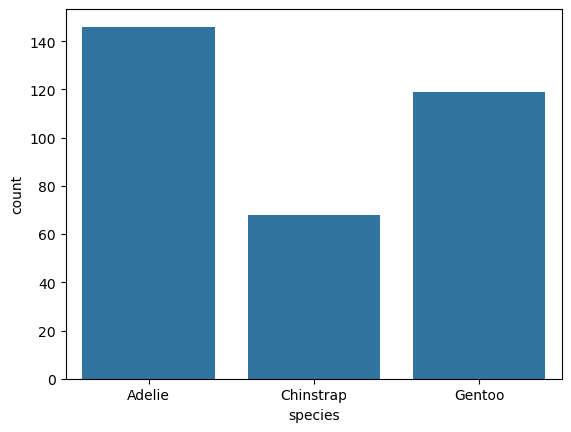

In [9]:
sns.countplot(data=df, x="species")
plt.show()

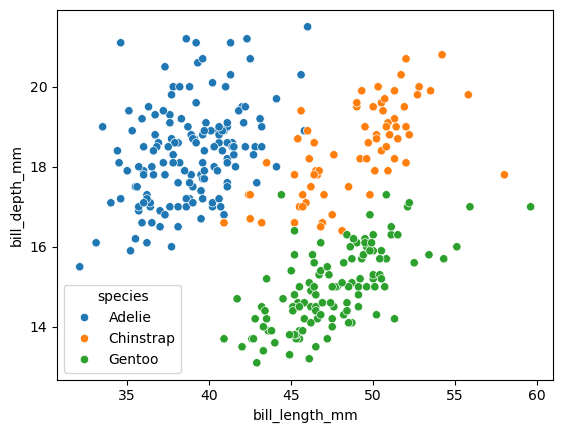

In [10]:
sns.scatterplot(
    data=df,
    x="bill_length_mm",
    y="bill_depth_mm",
    hue="species"
)
plt.show()

In [11]:
df_encoded = pd.get_dummies(
    df,
    columns=["island", "sex"],
    dtype=int
)

In [12]:
df_encoded

,species,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,island_Biscoe,island_Dream,island_Torgersen,sex_Female,sex_Male
0,Adelie,39.1,18.7,181.0,3750.0,0,0,1,0,1
1,Adelie,39.5,17.4,186.0,3800.0,0,0,1,1,0
2,Adelie,40.3,18.0,195.0,3250.0,0,0,1,1,0
4,Adelie,36.7,19.3,193.0,3450.0,0,0,1,1,0
5,Adelie,39.3,20.6,190.0,3650.0,0,0,1,0,1
...,...,...,...,...,...,...,...,...,...,...
338,Gentoo,47.2,13.7,214.0,4925.0,1,0,0,1,0
340,Gentoo,46.8,14.3,215.0,4850.0,1,0,0,1,0
341,Gentoo,50.4,15.7,222.0,5750.0,1,0,0,0,1
342,Gentoo,45.2,14.8,212.0,5200.0,1,0,0,1,0


In [13]:
X = df_encoded.drop("species", axis=1).values
y = df_encoded["species"].values

In [14]:
X

array([[ 39.1,  18.7, 181. , ...,   1. ,   0. ,   1. ],
       [ 39.5,  17.4, 186. , ...,   1. ,   1. ,   0. ],
       [ 40.3,  18. , 195. , ...,   1. ,   1. ,   0. ],
       ...,
       [ 50.4,  15.7, 222. , ...,   0. ,   0. ,   1. ],
       [ 45.2,  14.8, 212. , ...,   0. ,   1. ,   0. ],
       [ 49.9,  16.1, 213. , ...,   0. ,   0. ,   1. ]])

In [15]:
y

array(['Adelie', 'Adelie', 'Adelie', 'Adelie', 'Adelie', 'Adelie',
       'Adelie', 'Adelie', 'Adelie', 'Adelie', 'Adelie', 'Adelie',
       'Adelie', 'Adelie', 'Adelie', 'Adelie', 'Adelie', 'Adelie',
       'Adelie', 'Adelie', 'Adelie', 'Adelie', 'Adelie', 'Adelie',
       'Adelie', 'Adelie', 'Adelie', 'Adelie', 'Adelie', 'Adelie',
       'Adelie', 'Adelie', 'Adelie', 'Adelie', 'Adelie', 'Adelie',
       'Adelie', 'Adelie', 'Adelie', 'Adelie', 'Adelie', 'Adelie',
       'Adelie', 'Adelie', 'Adelie', 'Adelie', 'Adelie', 'Adelie',
       'Adelie', 'Adelie', 'Adelie', 'Adelie', 'Adelie', 'Adelie',
       'Adelie', 'Adelie', 'Adelie', 'Adelie', 'Adelie', 'Adelie',
       'Adelie', 'Adelie', 'Adelie', 'Adelie', 'Adelie', 'Adelie',
       'Adelie', 'Adelie', 'Adelie', 'Adelie', 'Adelie', 'Adelie',
       'Adelie', 'Adelie', 'Adelie', 'Adelie', 'Adelie', 'Adelie',
       'Adelie', 'Adelie', 'Adelie', 'Adelie', 'Adelie', 'Adelie',
       'Adelie', 'Adelie', 'Adelie', 'Adelie', 'Adelie', 'Adel

In [16]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)

In [17]:
y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,

In [18]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,
                                    test_size=0.2,
                                    random_state=42,
                                    stratify=y)

In [72]:
print(torch.bincount(y_train))
print(torch.bincount(y_test))

tensor([117,  54,  95])
tensor([29, 14, 24])


In [19]:
y_test

array([2, 1, 0, 2, 2, 2, 1, 0, 0, 2, 1, 0, 0, 1, 1, 0, 1, 0, 1, 2, 1, 2,
       0, 2, 2, 0, 0, 0, 2, 1, 2, 0, 0, 0, 0, 0, 2, 2, 0, 0, 0, 2, 2, 2,
       1, 0, 2, 1, 2, 1, 2, 0, 1, 0, 2, 0, 0, 1, 0, 2, 0, 2, 2, 0, 2, 0,
       0])

In [20]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)  # sadece eğitim verisinde fit
X_test = scaler.transform(X_test)         # testte yalnız transform

In [21]:
X_train = torch.tensor(X_train, dtype = torch.float32)
X_test = torch.tensor(X_test, dtype = torch.float32)

y_train = torch.tensor(y_train, dtype = torch.long)
y_test = torch.tensor(y_test, dtype = torch.long)

In [22]:
import torch.nn as nn

In [23]:
print(X.shape)

(333, 9)


In [24]:
print(y.shape)

(333,)


In [25]:
class PenguinClassifier(nn.Module):
    def __init__(self):
        super().__init__()

        self.linear_layer_stack = nn.Sequential(
            nn.Linear(in_features=9, out_features=16),
            nn.ReLU(),
            nn.Linear(in_features=16, out_features=16),
            nn.ReLU(),
            nn.Linear(in_features=16, out_features=16),
            nn.ReLU(),
            nn.Linear(in_features=16, out_features=3),
        )

    def forward(self, x):
        return self.linear_layer_stack(x)

In [26]:
from torchmetrics.classification import MulticlassAccuracy

In [27]:
accuracy = MulticlassAccuracy(num_classes=3)

In [104]:
model = PenguinClassifier()
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model.parameters(),lr=0.001)

epochs = 250

for epoch in range(epochs):
    model.train()
    logits = model(X_train)
    loss = loss_fn(logits,y_train)

    pred = torch.softmax(logits,dim=1).argmax(dim=1)
    acc = accuracy(pred,y_train).item() * 100

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    model.eval()
    with torch.inference_mode():
        test_logits = model(X_test)
        test_loss = loss_fn(test_logits,y_test)

        test_pred = torch.softmax(test_logits,dim=1).argmax(dim=1)
        test_acc = accuracy(test_pred,y_test).item() * 100

    if epoch % 20 == 0:
        print(f"Epoch: {epoch} | Loss: {loss:.5f}, Acc: {acc:.2f}% | Test Loss: {test_loss:.5f}, Test Acc: {test_acc:.2f}%")

Epoch: 0 | Loss: 1.16287, Acc: 37.65% | Test Loss: 1.15494, Test Acc: 42.86%
Epoch: 20 | Loss: 1.10944, Acc: 66.67% | Test Loss: 1.10455, Test Acc: 66.67%
Epoch: 40 | Loss: 1.03776, Acc: 67.24% | Test Loss: 1.03367, Test Acc: 68.97%
Epoch: 60 | Loss: 0.91221, Acc: 79.11% | Test Loss: 0.90558, Test Acc: 71.59%
Epoch: 80 | Loss: 0.70781, Acc: 66.67% | Test Loss: 0.70181, Test Acc: 66.67%
Epoch: 100 | Loss: 0.49516, Acc: 66.67% | Test Loss: 0.49114, Test Acc: 66.67%
Epoch: 120 | Loss: 0.30852, Acc: 96.30% | Test Loss: 0.29903, Test Acc: 97.62%
Epoch: 140 | Loss: 0.17457, Acc: 99.38% | Test Loss: 0.16392, Test Acc: 100.00%
Epoch: 160 | Loss: 0.09150, Acc: 99.38% | Test Loss: 0.08493, Test Acc: 100.00%
Epoch: 180 | Loss: 0.04906, Acc: 99.38% | Test Loss: 0.04685, Test Acc: 100.00%
Epoch: 200 | Loss: 0.03043, Acc: 100.00% | Test Loss: 0.03162, Test Acc: 98.85%
Epoch: 220 | Loss: 0.02170, Acc: 100.00% | Test Loss: 0.02481, Test Acc: 98.85%
Epoch: 240 | Loss: 0.01660, Acc: 100.00% | Test Loss:

In [106]:
from torchmetrics.classification import MulticlassConfusionMatrix
cm = MulticlassConfusionMatrix(num_classes=3)
matrix = cm(test_pred, y_test)
print(matrix)

tensor([[28,  1,  0],
        [ 0, 14,  0],
        [ 0,  0, 24]])


(<Figure size 640x480 with 1 Axes>,
 <Axes: xlabel='Predicted class', ylabel='True class'>)

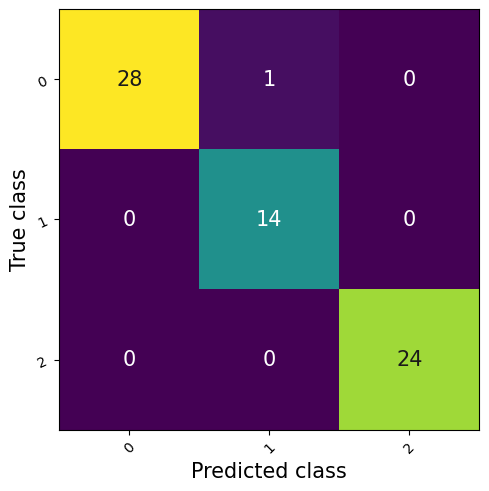

In [108]:
from torchmetrics.utilities.plot import plot_confusion_matrix
plot_confusion_matrix(matrix)

In [120]:
new_sample = np.array([[49.0, 16.1, 213, 5400, 1, 0, 0, 0, 1]])

new_sample_scaled = scaler.transform(new_sample)

new_sample_tensor = torch.tensor(
    new_sample_scaled,
    dtype=torch.float32
)

In [122]:
model.eval()

with torch.inference_mode():
    logits = model(new_sample_tensor)
    probabilities = torch.softmax(logits, dim=1)
    prediction = probabilities.argmax(dim=1)

print(prediction.item())

2


In [126]:
label_encoder.inverse_transform([prediction])

/opt/anaconda3/lib/python3.12/site-packages/sklearn/preprocessing/_label.py:151: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


array(['Gentoo'], dtype=object)